In [ ]:
import scipy as sp
import numpy as np
import pandas as pd
from skimage import feature, measure, restoration
import matplotlib.pyplot as plt
import cv2
import glob

# =============================================================================
# All In One: Orientation and Defect Analysis
# =============================================================================
def analyze_defects(img, sigma=15):
    """
    Find orentaion and defects from raw image
    img: image (phase contrast or fluorescence)
    sigma: standard deviation for Gaussian filter used in orientation analysis
    Returns:
        ori: orientation of the image
        plushalf: DataFrame of positive defects with charge +0.5    
        minushalf: DataFrame of negative defects with charge -0.5
    """
    # Calculate mgrid
    yy, xx = np.mgrid[0:img.shape[0], 0:img.shape[1]]
    
    # Calculate orientation analysis
    ori, coh, E = orientation_analysis(img, sigma)
    
    # Compute topological charges
    k = compute_topological_charges(-ori, int_area='cell', origin='lower')
    
    # Localize defects
    defects = localize_defects(k)#, x_grid=xx, y_grid=yy)
    
    # Compute defect orientation
    compute_defect_orientations(-ori, defects, method='interpolation', x_grid=xx[0,:], y_grid=yy[:,0], interpolation_radius=5, min_sep=1)
    
    # Filter defects by charge
    plushalf = defects[defects['charge']==.5]
    minushalf = defects[defects['charge']==-.5]
    
    return ori, plushalf, minushalf

# =============================================================================
# Orientation Analysis
# =============================================================================

def orientation_analysis(img, sigma=11):
    """ Orientation Analysis as in OrientationJ (Fiji). See https://forum.image.sc/t/orientationj-or-similar-for-python/51767/3 for a discussion.
    Also check theoretical-background-orientation.pdf for mathematical concepts. """
    # Compute structure tensor (upper diagonal elements) for every pixel in the image. Structre tensor is postive-definite symmetric matrix (positive eigenvalues)
    Axx, Axy, Ayy = feature.structure_tensor(img.astype(np.float32), sigma=sigma, mode='reflect', order='xy')
    # Get orientation for every pixel in the image
    ori = np.arctan2(2*Axy, Ayy - Axx) / 2
    # Compute coherence (local anisotropy of the image). If both eigenvalues of the structure tensor are equal, the coherence is zero (isotropic image). 
    # If the smaller eigenvalue tends to zero, the coherence tends to 1 (see math formulas).
    l1, l2 = feature.structure_tensor_eigenvalues([Axx, Axy, Ayy])
    eps = 1e-3 # to avoid division by zero?
    coh = ((l2-l1) / (l2+l1+eps)) ** 2
    # Finally, compute energy as trace of the structure tensor
    E = np.sqrt(Axx + Ayy)
    E /= np.max(E)
    return ori, coh, E

# =============================================================================
# Computation of topological charges
# =============================================================================

def compute_topological_charges(phi, type='nematic', int_area='cell', width=1, boundary='real', origin='upper'):
    # Get angles of grid points on the integration path.
    int_angles = get_angles_on_integration_path(phi, int_area, width, origin)
    # Compute the topological charges for all points by computing differences along the integration path.
    k = np.zeros_like(phi)
    for i in range(len(int_angles)-1):
        k += modulo(int_angles[i+1] - int_angles[i], type)
    # Some boundary values have to be discarded for non-periodic data depending on the integration path
    if boundary!='periodic':
        discard_boundary_values(k, int_area, width)
    return k/(2*np.pi)

def get_angles_on_integration_path(phi, int_area='square', width=1, origin='upper'):
    if int_area=='cell': #2x2 square in old reference
        e = np.roll(phi,-1,axis=1) # eastern neighbor
        n = np.roll(phi,1,axis=0) # northern neighbor
        ne = np.roll(e,1,axis=0) # northeastern neighbor
        int_angles = [e, ne, n, phi, e]
    if int_area=='square':
        e = np.roll(phi,-width,axis=1) # eastern neighbor
        w = np.roll(phi,width,axis=1) # western neighbor
        n = np.roll(phi,width,axis=0) # northern neighbor
        s = np.roll(phi,-width,axis=0) # southern neighbor
        ne = np.roll(e,width,axis=0)
        se = np.roll(e,-width,axis=0)
        nw = np.roll(w,width,axis=0)
        sw = np.roll(w,-width,axis=0)
        int_angles = [e, ne, n, nw, w, sw, s, se, e]
    # Check where the origin is (compare imshow vs. plot) and change the integration order accordingly    
    if origin=='lower':
        int_angles.reverse()
    return int_angles

def modulo(x, type='nematic'):
    """ Customized modulo function to remap [-pi,pi) to [-pi/2,pi/2) (nematic case) 
    or [-2pi,2pi) to [-pi,pi) (polar case). """
    if type=='polar':
        x[x>=np.pi] -= 2*np.pi
        x[x<-np.pi] += 2*np.pi
    if type=='nematic':
        x[x>=np.pi/2] -= np.pi
        x[x<-np.pi/2] += np.pi
    return x

def discard_boundary_values(k, int_area='square', width=1):
    """ Discard values at the boundary depending on the choosen integration path """
    if int_area=='cell':
        k[0,:], k[:,-1] = 0, 0
    if int_area=='square':
        k[:width+1,:], k[-width:,:], k[:,:width+1], k[:,-width:] = 0, 0, 0, 0


        
# =============================================================================
# Defect localization
# =============================================================================

def localize_defects(k, x_grid=None, y_grid=None, type='nematic', path='cell', thres=.1):
    ''' Localize defects based on the computed charges and the grid '''
    k_in = get_charge_interval(k, type)
    # Prepare data structure
    columns = ['charge','x','y','x_ind','y_ind']
    defects = pd.DataFrame({'charge': pd.Series(dtype=float),
                            'x' : pd.Series(dtype=float),
                            'y' : pd.Series(dtype=float),
                            'x_ind' : pd.Series(dtype=int),
                            'y_ind' : pd.Series(dtype=int),  
                            })
    if y_grid is None: # Check if grid is provided. Otherwise construct pseudo-grid
        x_grid, y_grid = np.meshgrid(np.arange(k.shape[0]),np.arange(k.shape[1]))
    # Iterate over charges
    for c in k_in:
        if c==0: # Skip charge zero, as there is no defect
            continue
        # Find charges with some threshold values and compute connected domains.
        # For each domain key information is stored.
        pos = (k>c-thres) & (k<c+thres)
        pos = measure.label(pos)
        for region in measure.regionprops(pos):
            x_ind = int(region.centroid[1]) # Some flip x/y again?
            y_ind = int(region.centroid[0])
            x = y_grid[x_ind,y_ind]
            y = x_grid[x_ind,y_ind]
            # if path=='cell': # Shift positions if integration area is a single cell.
            #     x += .5
            #     y += .5
            d = pd.DataFrame([[c, x, y, x_ind, y_ind]], columns=columns)
            defects = pd.concat([defects, d], ignore_index=True)
    return defects

def get_charge_interval(k, type='nematic'):
    '''Returns list of exact charges (-1/2,1/2,etc.) charges'''
    if type=='polar':
        min_k, max_k = round(np.min(k)), round(np.max(k))
        n = (max_k - min_k) + 1 # this assumes that min_k <= 0, which should be always the case, as 0 is lower bound.
    if type=='nematic':
        min_k, max_k = round_to_nearest_half_integer(np.min(k)), round_to_nearest_half_integer(np.max(k))
        n = int((max_k - min_k)*2 + 1) # this assumes that min_k <= 0, which should be always the case, as 0 is lower bound.
    return np.linspace(min_k, max_k, n)

def round_to_nearest_half_integer(x):
    return round(x*2)/2


# =============================================================================
# Defect orientation (so far only for (-1/2 and 1/2))
# =============================================================================

def compute_defect_orientations(phi, defects, **kwargs):
    '''Two methods to compute defect orientation, either based on
    derivatives of the orietation tensor (see Giomi) or comparing interpolated
    orientations with the defect orientation (brute-force).'''
    defect_orientation_interpolation(phi, defects, **kwargs)


def defect_orientation_interpolation(phi, defects, x_grid=None, y_grid=None, interpolation_radius=5, interpolation_points=100, interpolation_method='complex', min_sep=1, **kwargs):
    theta = np.linspace(0,2*np.pi,interpolation_points,endpoint=False)
    x_c = interpolation_radius*np.cos(theta)
    y_c = interpolation_radius*np.sin(theta)
    psi = np.arctan(y_c/x_c) # angle from defect to points on the circle
    int_ori = interpolate_orientation_field(phi, x_grid, y_grid, method=interpolation_method)
    plushalf = defects[defects['charge']==.5]
    minushalf = defects[defects['charge']==-.5]
    for index, row in plushalf.iterrows():
        phi_int = get_interpolated_angles(int_ori, plushalf.loc[index,'x']+x_c, plushalf.loc[index,'y']+y_c)
        diff = np.abs(modulo(phi_int-psi))
        indices = find_k_smallest_values(diff, k=1)
        defects.loc[index, 'ang1'] = np.arctan2(y_c[indices[0]],x_c[indices[0]])
    for index, row in minushalf.iterrows():
        phi_int = get_interpolated_angles(int_ori, minushalf.loc[index,'x']+x_c, minushalf.loc[index,'y']+y_c)
        diff = np.abs(modulo(phi_int-psi))
        indices = find_k_smallest_values(diff, k=3, min_sep=min_sep)
        defects.loc[index, ['ang1','ang2','ang3']] = np.arctan2(y_c[indices],x_c[indices])

def interpolate_orientation_field(phi, x, y, method='complex'):
    '''Different approaches to interpolate an orientation field.
    Complex (mapping to a circle) works best. Maybe a better interpolation routine can be used?'''
    if method=='unwrap_np': 
        phi_unwraped = np.unwrap(np.unwrap(phi,period=np.pi,axis=0),period=np.pi,axis=1)
        # return sp.interpolate.interp2d(x,y,phi_unwraped)
        return sp.interpolate.RectBivariateSpline(x,y,phi_unwraped.T)
    if method=='unwrap_scikit':
        phi_unwraped = restoration.unwrap_phase(2*phi)/2
        # return sp.interpolate.interp2d(x,y,phi_unwraped)
        return sp.interpolate.RectBivariateSpline(x,y,phi_unwraped.T)
    if method=='complex':
        # Strech to [-pi,pi) and interpolate real an imaginary part separetly.
        c = np.exp(2j*phi)
        # interp_r = sp.interpolate.interp2d(x,y,np.real(c))
        # interp_i = sp.interpolate.interp2d(x,y,np.imag(c))
        interp_r = sp.interpolate.RectBivariateSpline(x,y,np.real(c).T)
        interp_i = sp.interpolate.RectBivariateSpline(x,y,np.imag(c).T)        
        return [interp_r, interp_i]

def get_interpolated_angles(interp, x, y, method='complex'):
    '''Evaluate interpolated function depending on the choosen method.'''
    phi = np.zeros(len(x))
    for i in range(len(x)):
        if method=='complex':
            # Combine real and imaginary part and map back to [-pi/2,pi/2) again
            phi[i] = np.angle(
                    interp[0](x[i], y[i]).item() + 1j * interp[1](x[i], y[i]).item()
                    ) / 2.0

        else:
            phi[i] = modulo(interp(x[i],y[i]))
    return phi

def find_k_smallest_values(arr, k=3, min_sep=1):
    '''Custom funktion to find smallest values in an array that are at least min_sep inidices apart from each other. 
    The second criterion is needed to avoid to minima which are too close to each other.'''
    x = np.copy(arr) # this might be slow, but easier to code
    n = len(x)
    indices = []
    # Iterate over indices and find minima which fullfills the criterion.
    while len(indices)<k:
        ind = np.argmin(x)
        is_too_close = 0
        for i in indices:
            for j in range(min_sep):
                if (ind==(i+j+1)%n) | ((ind==(i-j-1)%n)):
                    is_too_close += 1
        if is_too_close==0:
            indices.append(ind)
        x[ind] = np.inf
    return indices

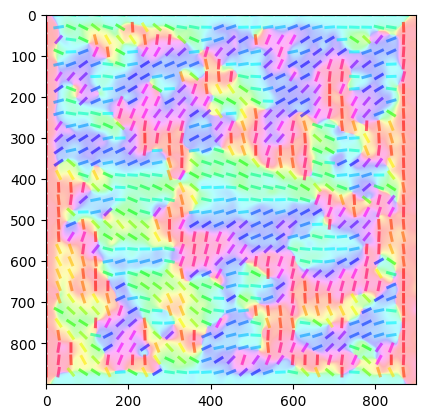

In [ ]:
%matplotlib inline
# Calculate orientation analysis
image_list = glob.glob(r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\ISF defects new\6\*.tif")

img = cv2.imread(image_list[0],0)[:,:900]
ori, _, _ = orientation_analysis(img, sigma=11)

plt.imshow(ori, cmap='hsv', alpha=0.3)
# plt.imshow(np.zeros_like(ori, dtype=np.float32), cmap="gray")

y, x = np.mgrid[0:ori.shape[0], 0:ori.shape[1]]

s = 30
plt.quiver(x[::s,::s], y[::s,::s],
    np.cos(ori[::s,::s]), np.sin(ori[::s,::s]), 
    np.arctan2(np.sin(ori[::s,::s]), np.cos(ori[::s,::s])),
    headaxislength=0, headwidth=0, headlength=0, width=.008, scale=35, pivot='mid', 
    alpha=.6, cmap='hsv')


In [ ]:
k = compute_topological_charges(-ori, int_area='cell', origin='lower')
k.min(), k.max(), k

(np.float32(-0.50000006),
 np.float32(0.50000006),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32))

In [ ]:
defects = localize_defects(k)
defects.head()

,charge,x,y,x_ind,y_ind
0,-0.5,531.0,34.0,531,34
1,-0.5,835.0,49.0,835,49
2,-0.5,787.0,55.0,787,55
3,-0.5,334.0,66.0,334,66
4,-0.5,382.0,87.0,382,87


In [ ]:
# Calculate mgrid
yy, xx = np.mgrid[0:img.shape[0], 0:img.shape[1]]
# Compute defect orientation
compute_defect_orientations(-ori, defects, method='interpolation', x_grid=xx[0,:], y_grid=yy[:,0], interpolation_radius=5, min_sep=1)
defects.head()

,charge,x,y,x_ind,y_ind,ang1,ang2,ang3
0,-0.5,531.0,34.0,531,34,-2.890265,1.633628,-0.376991
1,-0.5,835.0,49.0,835,49,2.387610,-2.010619,0.188496
2,-0.5,787.0,55.0,787,55,-0.753982,-2.576106,1.507964
3,-0.5,334.0,66.0,334,66,2.199115,-2.324779,0.188496
4,-0.5,382.0,87.0,382,87,-2.827433,1.570796,-0.565487


In [ ]:
plushalf = defects[defects['charge']==.5]
minushalf = defects[defects['charge']==-.5]

In [ ]:
plushalf.head()

,charge,x,y,x_ind,y_ind,ang1,ang2,ang3
65,0.5,807.0,41.0,807,41,2.387610,NaN,NaN
66,0.5,850.0,52.0,850,52,2.953097,NaN,NaN
67,0.5,506.0,58.0,506,58,2.387610,NaN,NaN
68,0.5,28.0,65.0,28,65,-0.125664,NaN,NaN
69,0.5,785.0,69.0,785,69,-2.324779,NaN,NaN


In [ ]:
minushalf.head()

,charge,x,y,x_ind,y_ind,ang1,ang2,ang3
0,-0.5,531.0,34.0,531,34,-2.890265,1.633628,-0.376991
1,-0.5,835.0,49.0,835,49,2.387610,-2.010619,0.188496
2,-0.5,787.0,55.0,787,55,-0.753982,-2.576106,1.507964
3,-0.5,334.0,66.0,334,66,2.199115,-2.324779,0.188496
4,-0.5,382.0,87.0,382,87,-2.827433,1.570796,-0.565487


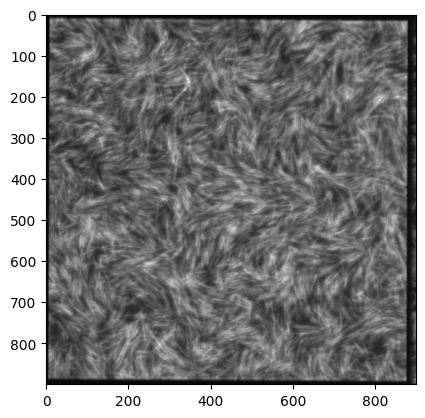

In [ ]:
image_list = glob.glob(r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\ISF defects new\6\*.tif")
img = cv2.imread(image_list[0],0)[:,:900]
plt.imshow(img, "gray")

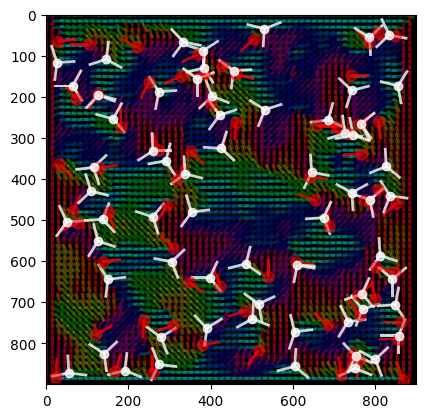

In [ ]:
%matplotlib inline   
# inline or qt

# plt.imshow(img, "gray")
plt.imshow(np.zeros_like(img, dtype=np.float32), cmap="gray")
ori, plus, min = analyze_defects(img, sigma=11)

y, x = np.mgrid[0:ori.shape[0], 0:ori.shape[1]]
s = 15
plt.quiver(x[::s,::s], y[::s,::s],
    np.cos(ori)[::s,::s], np.sin(ori)[::s,::s], np.arctan2(np.sin(ori), np.cos(ori))[::s,::s],
    headaxislength=0, headwidth=0, headlength=0, width=.008,
    scale=35, pivot='mid', alpha=.3, cmap="hsv")

alpha_half, scale_half = .8, 20    
plt.plot(plus['x'], plus['y'],'ro', markersize=8, alpha=.5)
plt.quiver(plus['x'], plus['y'], 
    np.cos(plus['ang1']), -np.sin(plus['ang1']), 
    headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

plt.plot(min['x'], min['y'],'wo',markersize=6, alpha=alpha_half)
for j in range(3):
    plt.quiver(min['x'], min['y'], 
        np.cos(min['ang'+str(j+1)]), -np.sin(min['ang'+str(j+1)]), 
        headaxislength=0, headwidth=0, headlength=0, color='w', scale=scale_half, alpha=alpha_half)

plt.gca().set_box_aspect(1)